# Automated Heuristic Discovery for TSP using FunSearch

## 1. Environment Initialization

This section initializes the computational environment to ensure experimental reproducibility. The core FunSearch framework and benchmark datasets are pulled directly from the version-controlled repository, establishing an isolated and consistent baseline for all subsequent heuristic evaluations.

* **Repository:** [https://github.com/askennry/TSP-FunSearch](https://github.com/askennry/TSP-FunSearch)

In [1]:
import os
import sys
import subprocess

# --- 1. Global Configurations ---
REPO_URL = "https://github.com/askennry/TSP-FunSearch.git"
WORK_DIR = "/content/TSP-FunSearch"

def initialize_environment():
    """Clones the repository and configures paths."""
    print("Initializing environment...")

    # Clone or update repository
    if not os.path.exists(WORK_DIR):
        subprocess.run(["git", "clone", REPO_URL, WORK_DIR], check=True, capture_output=True)
    else:
        subprocess.run(["git", "-C", WORK_DIR, "pull"], check=True, capture_output=True)

    # Update system path
    if WORK_DIR not in sys.path:
        sys.path.append(WORK_DIR)

def verify_assets():
    """Validates the presence of required modules and datasets."""
    impl_dir = os.path.join(WORK_DIR, 'implementation')
    # Automatically check 'dataset' or 'data' folder based on your repo structure
    data_file_v1 = os.path.join(WORK_DIR, 'dataset', 'a280.tsp')
    data_file_v2 = os.path.join(WORK_DIR, 'data', 'a280.tsp')

    has_impl = os.path.exists(impl_dir)
    has_data = os.path.exists(data_file_v1) or os.path.exists(data_file_v2)

    if has_impl and has_data:
        print("Setup complete: Implementation and datasets verified.")
    else:
        print("Error: Missing critical project files (implementation or dataset).")

# --- 2. Execute ---
initialize_environment()
verify_assets()

Initializing environment...
Setup complete: Implementation and datasets verified.


## 2. Dependencies and Core Problem Formulation

This section installs the required `tsplib95` library silently and defines the `TSPProblem` class. This class handles parsing standard `.tsp` files, constructing distance matrices, and calculating tour lengths.

In [2]:
!pip install tsplib95 -q

import os
import glob
import math
import random
from itertools import chain
from functools import partial
from typing import List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tsplib95
from scipy.spatial.distance import squareform, pdist

class TSPProblem:
    def __init__(self, problem_path=None):
        problem = tsplib95.load(problem_path)
        self.name = problem.name
        self.dimension = problem.dimension

        if problem.edge_weight_type == 'EXPLICIT':
            # Nodes
            self.nodes = pd.DataFrame.from_dict(problem.display_data, orient='index', columns=['x', 'y'])

            # Distance matrix mapping
            if problem.edge_weight_format == 'FULL_MATRIX':
                self.distance_matrix = problem.edge_weights
            else:
                if problem.edge_weight_format == 'LOWER_DIAG_ROW':
                    idx = np.tril_indices(self.dimension)
                if problem.edge_weight_format == 'UPPER_ROW':
                    idx = np.triu_indices(self.dimension, k=1)
                if problem.edge_weight_format == 'UPPER_DIAG_ROW':
                    idx = np.triu_indices(self.dimension)

                distance = list(chain(*problem.edge_weights))
                self.distance_matrix = np.zeros((self.dimension, self.dimension))
                self.distance_matrix[idx] = distance
                self.distance_matrix[idx[1], idx[0]] = distance
        else:
            # Nodes
            self.nodes = pd.DataFrame.from_dict(problem.node_coords, orient='index', columns=['x', 'y'])

            # Distance calculation based on TSPLIB standards
            if problem.edge_weight_type == 'EUC_2D':
                self.distance_matrix = squareform(pdist(self.nodes, tsplib95.distances.euclidean))
            if problem.edge_weight_type == 'CEIL_2D':
                self.distance_matrix = squareform(pdist(self.nodes, partial(tsplib95.distances.euclidean, round=math.ceil)))
            if problem.edge_weight_type == 'GEO':
                self.distance_matrix = squareform(pdist(self.nodes, tsplib95.distances.geographical))
            if problem.edge_weight_type == 'ATT':
                self.distance_matrix = squareform(pdist(self.nodes, tsplib95.distances.pseudo_euclidean))

        self.distance_matrix = pd.DataFrame(self.distance_matrix, index=range(1, self.dimension+1), columns=range(1, self.dimension+1))

        # Optimal tour mapping
        opt_path = os.path.splitext(problem_path)[0] + '.opt.tour'
        if os.path.isfile(opt_path):
            opt = tsplib95.load(opt_path)
            self.optimal_tour = opt.tours[0]
        else:
            self.optimal_tour = None

    def get_tour_length(self, tour: List[int]) -> float:
        length = 0
        for i in range(len(tour)):
            length += self.distance_matrix[tour[i]][tour[(i+1)%len(tour)]]
        return length

    def plot_tour(self, tour: List[int]):
        plt.figure(figsize=(10, 6))

        # Plot nodes
        x = self.nodes.x
        y = self.nodes.y
        plt.scatter(x, y, color='#E53528', zorder=2)

        # Annotate node indices
        for i in range(self.dimension):
            plt.annotate(str(i+1), (x[i+1], y[i+1]), fontsize=6, xytext=(2, 2), textcoords='offset points')

        # Plot tour edges
        for i in range(len(tour)):
            start = tour[i]
            end = tour[(i+1)%len(tour)]
            plt.plot([x[start], x[end]], [y[start], y[end]], color='#55B7E6', zorder=1)

        plt.title(f'{self.name} - Length: {self.get_tour_length(tour):.2f}')
        plt.show()

## 3. Dataset Visualization

We instantiate the `TSPProblem` class using the `a280` dataset to verify that the environment and dataset mappings are functioning correctly.

Preview of a280 nodes:
     x    y
1  288  149
2  288  129
3  270  133
4  256  141
5  256  157


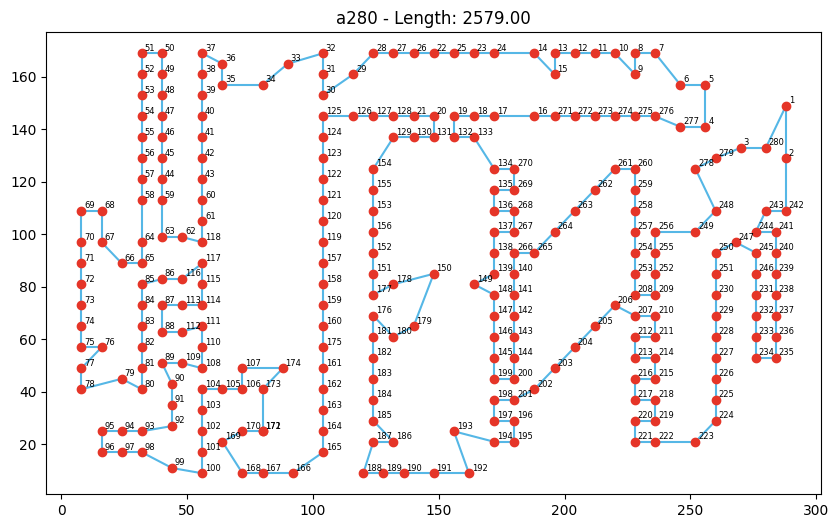

In [3]:
# Use local repository path instead of Google Drive
WORK_DIR = '/content/group_project_tsp'
a280_path = os.path.join(WORK_DIR, 'data', 'a280.tsp')

a280 = TSPProblem(a280_path)
print("Preview of a280 nodes:")
print(a280.nodes.head())

if a280.optimal_tour:
    a280.plot_tour(a280.optimal_tour)
else:
    print("Optimal tour not found for plotting.")

## 4. Benchmark Preparation and Log Initialization

We load a designated subset of TSPLIB benchmark instances into memory. Additionally, we create a local log directory to save the outputs of the evolutionary process.

In [4]:
LOG_DIR = '/content/funsearch_logs'
os.makedirs(LOG_DIR, exist_ok=True)
print(f"Log directory initialized at: {LOG_DIR}")

dataset_paths = [
    f'{WORK_DIR}/data/a280.tsp',
    f'{WORK_DIR}/data/att48.tsp',
    f'{WORK_DIR}/data/bayg29.tsp',
    f'{WORK_DIR}/data/bays29.tsp',
    f'{WORK_DIR}/data/berlin52.tsp'
]

dataset = {}

for path in dataset_paths:
    if not os.path.exists(path):
        print(f"Failed to find: {path}")
        continue

    problem = TSPProblem(path)
    dataset[problem.name] = problem.distance_matrix.to_numpy()
    print(f"Loaded dataset: {problem.name}")

print("Dataset preparation complete.")

Log directory initialized at: /content/funsearch_logs
Loaded dataset: a280
Loaded dataset: att48
Loaded dataset: bayg29
Loaded dataset: bays29
Loaded dataset: berlin52
Dataset preparation complete.


## 5. LLM API Integration and Output Parsing

This section configures the interface between the FunSearch evaluator and the external Large Language Model. Because standard conversational models often output conversational text alongside code, the `_trim_preface_of_body` utility is implemented to isolate the raw Python logic. The `LLMAPI` class handles the HTTP requests, prompting, and robust error handling (retries) during the multiprocess evolutionary search.

In [ ]:
import time
import json
import http.client
from typing import Collection
from implementation import sampler

# API Configuration
API_KEY = ''

def _trim_preface_of_body(sample: str) -> str:
    """
    Trims redundant descriptions or function signatures generated by the LLM.
    Extracts only the code block following the first 'def' declaration to maintain
    compatibility with the strict FunSearch sandbox execution.
    """
    lines = sample.splitlines()
    func_body_lineno = 0
    find_def_declaration = False

    for lineno, line in enumerate(lines):
        if line.startswith('def'):
            func_body_lineno = lineno
            find_def_declaration = True
            break

    if find_def_declaration:
        # Reconstruct the string keeping the original indentation
        code = '\n'.join(lines[func_body_lineno + 1:]) + '\n'
        return code

    return sample

class LLMAPI(sampler.LLM):
    """Language model wrapper that predicts continuations of provided source code."""

    def __init__(self, samples_per_prompt: int, trim=True):
        super().__init__(samples_per_prompt)
        self._additional_prompt = (
            'Complete a different and more complex Python function. '
            'Be creative and you can insert multiple if-else and for-loop in the code logic. '
            'Only output the Python code, no descriptions.'
        )
        self._trim = trim

    def draw_samples(self, prompt: str) -> Collection[str]:
        """Returns multiple predicted continuations of the prompt."""
        return [self._draw_sample(prompt) for _ in range(self._samples_per_prompt)]

    def _draw_sample(self, content: str) -> str:
        prompt = f"{content}\n{self._additional_prompt}"

        while True:
            try:
                conn = http.client.HTTPSConnection("api.bltcy.ai")
                payload = json.dumps({
                    "max_tokens": 512,
                    "model": "gpt-3.5-turbo",
                    "messages": [
                        {
                            "role": "user",
                            "content": prompt
                        }
                    ]
                })
                headers = {
                    'Authorization': f'Bearer {API_KEY}',
                    'User-Agent': 'Apifox/1.0.0 (https://apifox.com)',
                    'Content-Type': 'application/json'
                }

                conn.request("POST", "/v1/chat/completions", payload, headers)
                res = conn.getresponse()
                data = json.loads(res.read().decode("utf-8"))

                response = data['choices'][0]['message']['content']

                # Apply extraction logic if enabled
                if self._trim:
                    response = _trim_preface_of_body(response)

                return response
            except Exception:
                # Robustness against rate limits or temporary network issues
                time.sleep(2)
                continue

## 6. Secure Execution Sandbox

To safely evaluate the potentially unpredictable code generated by the LLM, we define a robust `Sandbox` environment. This class utilizes the `multiprocessing` library to execute generated heuristics in isolated processes. It enforces strict time constraints (timeouts) to prevent infinite loops and optionally applies Numba JIT compilation to accelerate the evaluation of valid programs.

In [6]:
from implementation import evaluator
from implementation import evaluator_accelerate
import multiprocessing
from typing import Any

class Sandbox(evaluator.Sandbox):
    """
    Sandbox for securely executing LLM-generated heuristics.
    Ensures execution stays within resource limits and prevents infinite loops
    via multiprocessing and timeout management.
    """

    def __init__(self, verbose=False, numba_accelerate=True):
        """
        Args:
            verbose: If True, prints evaluation information.
            numba_accelerate: If True, uses Numba JIT compilation to accelerate evaluation.
                              Note: Not all NumPy functions are supported by Numba.
        """
        self._verbose = verbose
        self._numba_accelerate = numba_accelerate

    def run(
            self,
            program: str,
            function_to_run: str,
            function_to_evolve: str,
            inputs: Any,
            test_input: str,
            timeout_seconds: int,
            **kwargs
    ) -> tuple[Any, bool]:
        """
        Executes the generated code safely in an isolated process.

        Args:
            program: The LLM-generated raw Python code.
            function_to_run: The name of the entry-point evaluation function.
            function_to_evolve: The name of the target heuristic function to accelerate.
            inputs: The dictionary of available datasets.
            test_input: The key mapping to the specific dataset instance.
            timeout_seconds: Maximum allowed execution time before forced termination.

        Returns:
            A tuple containing the evaluation score (if successful) and a boolean indicating success.
        """
        dataset = inputs[test_input]
        try:
            result_queue = multiprocessing.Queue()
            process = multiprocessing.Process(
                target=self._compile_and_run_function,
                args=(program, function_to_run, function_to_evolve, dataset, self._numba_accelerate, result_queue)
            )
            process.start()
            process.join(timeout=timeout_seconds)

            if process.is_alive():
                # Terminate if the execution exceeds the timeout (e.g., infinite loop)
                process.terminate()
                process.join()
                results = None, False
            else:
                if not result_queue.empty():
                    results = result_queue.get_nowait()
                else:
                    results = None, False

            return results
        except Exception:
            return None, False

    def _compile_and_run_function(self, program, function_to_run, function_to_evolve, dataset, numba_accelerate, result_queue):
        """Compiles and executes the generated program within the isolated process."""
        try:
            # Accelerate the target heuristic using Numba JIT compilation
            if numba_accelerate:
                program = evaluator_accelerate.add_numba_decorator(
                    program=program,
                    function_to_evolve=function_to_evolve
                )

            # Compile the program into a local namespace
            all_globals_namespace = {}
            exec(program, all_globals_namespace)

            # Extract the pointer to the entry-point evaluation function
            func_to_run = all_globals_namespace[function_to_run]

            # Execute and collect the objective score
            results = func_to_run(dataset)

            # Validate that the output is a valid numerical score
            if not isinstance(results, (int, float)):
                result_queue.put((None, False))
                return

            result_queue.put((results, True))
        except Exception:
            # Catch all syntax or runtime errors and flag the execution as failed
            result_queue.put((None, False))

## 7. Baseline Heuristic and Local Testing

Before initiating the automated evolutionary search, we define the baseline greedy heuristic (Nearest Neighbor). We execute this baseline locally on the `a280` dataset to establish the starting performance metric.

In [7]:
import numpy as np

def tsp(distance_matrix):
    """Solves the Traveling Salesman Problem (TSP) using a greedy nearest-neighbor heuristic."""
    num_nodes = len(distance_matrix)
    start_node = 0
    tour = [start_node]
    visited = np.full(num_nodes, False, dtype=bool)
    visited[start_node] = True
    total_distance = 0

    while(len(tour) < num_nodes):
        priorities = np.ma.array(priority(distance_matrix, tour), mask=visited)

        next_node = int(np.ma.argmax(priorities))
        total_distance += distance_matrix[tour[-1]][next_node]
        tour.append(next_node)
        visited[next_node] = True

    total_distance += distance_matrix[tour[-1]][start_node]
    tour = [node + 1 for node in tour]
    return tour, total_distance

def evaluate(distance_matrix):
    """Evaluate heuristic function on a set of distance matrix instances."""
    tour, total_distance = tsp(distance_matrix)
    return -total_distance

def priority(distance_matrix, tour):
    """Returns priority with which we want to add node to tour."""
    num_nodes = len(distance_matrix)
    current_node = tour[-1]
    priorities = -distance_matrix[current_node]

    for node in range(num_nodes):
        if node in tour:
            priorities[node] = -float('inf')

    return priorities

# Execute local test on the a280 dataset
test_tour, test_total_distance = tsp(a280.distance_matrix.to_numpy())
print(f"Baseline Nearest-Neighbor distance on a280: {test_total_distance:.2f}")

Baseline Nearest-Neighbor distance on a280: 3157.00


## 8. FunSearch Specification Prompt

This block defines the exact framework that will be parsed by the LLM during the search process.
- The `@funsearch.evolve` decorator marks the `priority` function as the target for heuristic mutation.
- The `@funsearch.run` decorator designates the evaluation entry point for the Sandbox.

In [8]:
# --- The Trusted Baseline Specification Prompt ---
specification = r'''
import numpy as np

def tsp(distance_matrix):
    """Solves the Traveling Salesman Problem (TSP) using a greedy nearest-neighbor heuristic."""
    num_nodes = len(distance_matrix)
    start_node = 0
    tour = [start_node]
    visited = np.full(num_nodes, False, dtype=bool)
    visited[start_node] = True
    total_distance = 0

    while(len(tour) < num_nodes):
        priorities = np.ma.array(priority(distance_matrix, tour), mask=visited)

        next_node = int(np.ma.argmax(priorities))
        total_distance += distance_matrix[tour[-1]][next_node]
        tour.append(next_node)
        visited[next_node] = True

    total_distance += distance_matrix[tour[-1]][start_node]
    tour = [node + 1 for node in tour]
    return tour, total_distance

@funsearch.run
def evaluate(distance_matrix):
    """Evaluate heuristic function on a set of distance matrix instances."""
    tour, total_distance = tsp(distance_matrix)
    return -total_distance

@funsearch.evolve
def priority(distance_matrix, tour):
    """Returns priority with which we want to add node to tour.

    Args:
        distance_matrix: Square distance matrix of shape (n, n)
                         matrix[i][j] represents direct distance from node i to node j
                         Diagonal elements are not validated (should typically be 0)
        tour: Current path of visited nodes in visitation order

    Return: Priority array of shape (n,) where:
            - Negative values: priority for unvisited candidates
              (closer nodes have less negative values - e.g. -3 > -5 in priority)
            - -inf: already visited nodes
    """
    num_nodes = len(distance_matrix)
    current_node = tour[-1]
    priorities = -distance_matrix[current_node]

    for node in range(num_nodes):
        if node in tour:
            priorities[node] = -float('inf')

    return priorities
'''
print("Specification defined successfully.")

Specification defined successfully.


## 9. FunSearch Execution Pipeline

This final section initializes the configurations and triggers the main FunSearch loop.
- **Timeout Optimization:** The evaluation timeout is set to 60 seconds.
- **Log Persistence:** Outputs are routed to the previously configured local directory, allowing results to be saved securely before the Colab runtime disconnects.

In [9]:
from implementation import funsearch
from implementation import config
import time

if __name__ == '__main__':
    class_config = config.ClassConfig(llm_class=LLMAPI, sandbox_class=Sandbox)
    main_config = config.Config(samples_per_prompt=4, evaluate_timeout_seconds=60)
    global_max_sample_num = 500

    print("🚀 Starting FunSearch evolutionary process...")
    print(f"📁 Outputs will be safely stored in: {LOG_DIR}")
    print("-" * 50)

    start_time = time.time()

    try:
        funsearch.main(
            specification=specification,
            inputs=dataset,
            config=main_config,
            max_sample_nums=global_max_sample_num,
            class_config=class_config,
            log_dir=LOG_DIR
        )
    except KeyboardInterrupt:
        print("\n🛑 Evolutionary search manually interrupted by user.")
    finally:
        total_time = time.time() - start_time
        print("-" * 50)
        print(f"⏱️ Total Execution Time: {total_time:.2f} seconds ({total_time/60:.2f} minutes)")

🚀 Starting FunSearch evolutionary process...
📁 Outputs will be safely stored in: /content/funsearch_logs
--------------------------------------------------


INFO:absl:Best score of island 0 increased to -6750.75
INFO:absl:Best score of island 1 increased to -6750.75
INFO:absl:Best score of island 2 increased to -6750.75
INFO:absl:Best score of island 3 increased to -6750.75
INFO:absl:Best score of island 4 increased to -6750.75
INFO:absl:Best score of island 5 increased to -6750.75
INFO:absl:Best score of island 6 increased to -6750.75
INFO:absl:Best score of island 7 increased to -6750.75
INFO:absl:Best score of island 8 increased to -6750.75
INFO:absl:Best score of island 9 increased to -6750.75


================= Evaluated Function =================
def priority(distance_matrix, tour):
    """Returns priority with which we want to add node to tour.

    Args:
        distance_matrix: Square distance matrix of shape (n, n)
                         matrix[i][j] represents direct distance from node i to node j
                         Diagonal elements are not validated (should typically be 0)
        tour: Current path of visited nodes in visitation order

    Return: Priority array of shape (n,) where:
            - Negative values: priority for unvisited candidates
              (closer nodes have less negative values - e.g. -3 > -5 in priority)
            - -inf: already visited nodes
    """
    num_nodes = len(distance_matrix)
    current_node = tour[-1]
    priorities = -distance_matrix[current_node]

    for node in range(num_nodes):
        if node in tour:
            priorities[node] = -float('inf')

    return priorities
----------------------------------------------

INFO:absl:Best score of island 8 increased to -6664.0


================= Evaluated Function =================
def priority(distance_matrix, tour):
    """Returns priority with which we want to add node to tour.

    Args:
        distance_matrix: Square distance matrix of shape (n, n)
                         matrix[i][j] represents direct distance from node i to node j
                         Diagonal elements are not validated (should typically be 0)
        tour: Current path of visited nodes in visitation order

    Return: Priority array of shape (n,) where:
            - Negative values: priority for unvisited candidates
              (closer nodes have less negative values - e.g. -3 > -5 in priority)
            - -inf: already visited nodes
    """
    """More complex priority calculation that also considers how adding a node affects total future travel cost."""
    num_nodes = len(distance_matrix)
    current_node = tour[-1]
    priorities = np.full(num_nodes, -float('inf'))

    unvisited = [node for node in range(num_nodes) if 

...

================= Evaluated Function =================
def priority(distance_matrix, tour):
    """Returns priority with which we want to add node to tour.

    Args:
        distance_matrix: Square distance matrix of shape (n, n)
                         matrix[i][j] represents direct distance from node i to node j
                         Diagonal elements are not validated (should typically be 0)
        tour: Current path of visited nodes in visitation order

    Return: Priority array of shape (n,) where:
            - Negative values: priority for unvisited candidates
              (closer nodes have less negative values - e.g. -3 > -5 in priority)
            - -inf: already visited nodes
    """
    """Improved version of `priority_v1` with additional heuristics.

    Adds a penalty for nodes that are far from recent nodes in the tour,
    and bonuses nodes that connect to unvisited nodes with short distances.
    """
    num_nodes = len(distance_matrix)
    current_node = tour

<string>:57: NumbaTypeSafetyWarning: unsafe cast from Poison<LiteralStrKey[Dict]({Literal[str](count): int64, Literal[str](avg_dist): float64})> to Poison<Poison<LiteralStrKey[Dict]({Literal[str](count): int64, Literal[str](avg_dist): float64})>>. Precision may be lost.
<string>:57: NumbaTypeSafetyWarning: unsafe cast from Poison<LiteralStrKey[Dict]({Literal[str](count): int64, Literal[str](avg_dist): float64})> to Poison<Poison<LiteralStrKey[Dict]({Literal[str](count): int64, Literal[str](avg_dist): float64})>>. Precision may be lost.
<string>:57: NumbaTypeSafetyWarning: unsafe cast from Poison<LiteralStrKey[Dict]({Literal[str](count): int64, Literal[str](avg_dist): float64})> to Poison<Poison<LiteralStrKey[Dict]({Literal[str](count): int64, Literal[str](avg_dist): float64})>>. Precision may be lost.
<string>:57: NumbaTypeSafetyWarning: unsafe cast from Poison<LiteralStrKey[Dict]({Literal[str](count): int64, Literal[str](avg_dist): float64})> to Poison<Poison<LiteralStrKey[Dict]({Lite

流式输出内容被截断，只能显示最后 5000 行内容。
              (closer nodes have less negative values - e.g. -3 > -5 in priority)
            - -inf: already visited nodes
    """
    """More advanced priority calculation with multiple heuristics and dynamic weighting.

    Args:
        distance_matrix: Square distance matrix of shape (n, n)
        tour: Current path of visited nodes in visitation order

    Return:
        Priority array of shape (n,)
        - Negative values: priority for unvisited nodes (lower negative means higher priority)
        - -inf: visited nodes
    """
    num_nodes = len(distance_matrix)
    current_node = tour[-1]
    priorities = np.full(num_nodes, -float('inf'), dtype=float)
    visited_set = set(tour)

    # Calculate global metrics
    avg_distances = np.sum(distance_matrix, axis=1) / (num_nodes - 1)
    std_distances = np.std(distance_matrix, axis=1)

    # Dynamic weights for heuristics
    weight_distance = 0.5
    weight_neighbor = 0.3
    weight_cluster = 0.2

  

<string>:51: NumbaTypeSafetyWarning: unsafe cast from UniTuple(int64 x 2) to undefined. Precision may be lost.
<string>:51: NumbaTypeSafetyWarning: unsafe cast from int64 to undefined. Precision may be lost.
<string>:51: NumbaTypeSafetyWarning: unsafe cast from UniTuple(int64 x 2) to undefined. Precision may be lost.
<string>:51: NumbaTypeSafetyWarning: unsafe cast from int64 to undefined. Precision may be lost.
<string>:51: NumbaTypeSafetyWarning: unsafe cast from UniTuple(int64 x 2) to undefined. Precision may be lost.
<string>:51: NumbaTypeSafetyWarning: unsafe cast from int64 to undefined. Precision may be lost.
<string>:51: NumbaTypeSafetyWarning: unsafe cast from UniTuple(int64 x 2) to undefined. Precision may be lost.
<string>:51: NumbaTypeSafetyWarning: unsafe cast from int64 to undefined. Precision may be lost.
<string>:51: NumbaTypeSafetyWarning: unsafe cast from UniTuple(int64 x 2) to undefined. Precision may be lost.
<string>:51: NumbaTypeSafetyWarning: unsafe cast from int

================= Evaluated Function =================
def priority(distance_matrix, tour):
    """Returns priority with which we want to add node to tour.

    Args:
        distance_matrix: Square distance matrix of shape (n, n)
                         matrix[i][j] represents direct distance from node i to node j
                         Diagonal elements are not validated (should typically be 0)
        tour: Current path of visited nodes in visitation order

    Return: Priority array of shape (n,) where:
            - Negative values: priority for unvisited candidates
              (closer nodes have less negative values - e.g. -3 > -5 in priority)
            - -inf: already visited nodes
    """
    """More advanced priority calculation considering path diversity, penalties and adaptive scaling."""
    num_nodes = len(distance_matrix)
    current_node = tour[-1]
    priorities = np.full(num_nodes, -float('inf'))
    
    unvisited = [node for node in range(num_nodes) if node no

## 10. Post-Run Analysis and Summary

This section extracts the evolutionary history from the saved logs, plots the performance trajectory, and displays the best-discovered heuristic function without altering the core search engine.

Analyzing FunSearch Logs...


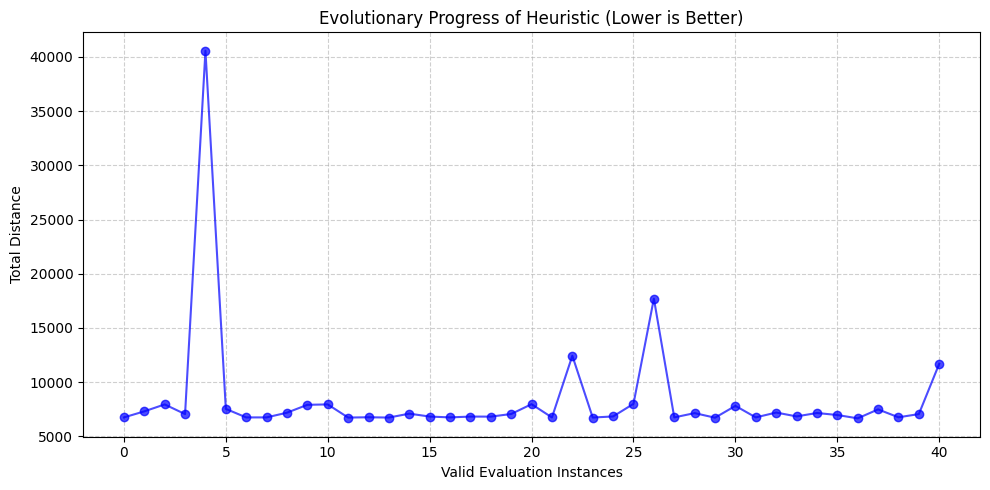


BEST SCORE FOUND: -6664.0 (Distance: 6664.0)
BEST EVOLVED HEURISTIC CODE:
--------------------------------------------------
def priority(distance_matrix, tour):
    """Returns priority with which we want to add node to tour.

    Args:
        distance_matrix: Square distance matrix of shape (n, n)
                         matrix[i][j] represents direct distance from node i to node j
                         Diagonal elements are not validated (should typically be 0)
        tour: Current path of visited nodes in visitation order

    Return: Priority array of shape (n,) where:
            - Negative values: priority for unvisited candidates
              (closer nodes have less negative values - e.g. -3 > -5 in priority)
            - -inf: already visited nodes
    """
    """More complex priority calculation that also considers how adding a node affects total future travel cost."""
    num_nodes = len(distance_matrix)
    current_node = tour[-1]
    priorities = np.full(num_nodes,

In [10]:
import os
import json
import glob
import matplotlib.pyplot as plt

def analyze_funsearch_results(log_directory):
    print("Analyzing FunSearch Logs...")

    # Locate all generated log files
    samples_dir = os.path.join(log_directory, 'samples')
    json_files = glob.glob(os.path.join(samples_dir, '*.json'))

    if not json_files:
        print("No log files found. The search might not have generated valid samples yet.")
        return

    history = []
    best_score = float('-inf')
    best_program = ""

    # Parse logs to extract scores and corresponding heuristic code
    for file_path in sorted(json_files):
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
                score = data.get('score')
                if score is not None:
                    # FunSearch objective is negated distance; higher score is better
                    history.append(score)
                    if score > best_score:
                        best_score = score
                        best_program = data.get('function', '')
        except Exception as e:
            continue

    if not history:
        print("No valid scores recorded in the logs (all evaluations failed or timed out).")
        return

    # --- 1. Visualization (Convergence Curve) ---
    plt.figure(figsize=(10, 5))

    # Convert scores back to positive distances for intuitive plotting (lower is better)
    distances = [-s for s in history]

    plt.plot(distances, marker='o', linestyle='-', color='b', alpha=0.7)
    plt.title("Evolutionary Progress of Heuristic (Lower is Better)")
    plt.xlabel("Valid Evaluation Instances")
    plt.ylabel("Total Distance")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # --- 2. Final Heuristic Extraction ---
    print("\n" + "="*50)
    print(f"BEST SCORE FOUND: {best_score} (Distance: {-best_score})")
    print("="*50)
    print("BEST EVOLVED HEURISTIC CODE:")
    print("-" * 50)
    print(best_program)
    print("-" * 50)

# Execute the analysis on the defined log directory
analyze_funsearch_results(LOG_DIR)